In [1]:
import warnings
warnings.filterwarnings("ignore")

import cv2
import os
import gc
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_curve, auc, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import timm

In [2]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [5]:
base = Path('/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23')
frames_base = Path('/kaggle/working/extracted_frames')
real_dir = frames_base / 'real'
fake_dir = frames_base / 'fake'

In [6]:
from pathlib import Path

base = Path('/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23')
frames_base = Path('/kaggle/working/extracted_frames')

SAVE_PATH = '/kaggle/working/best_deepfake_model.pth'
IMG_SIZE = 224

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [7]:
real_dir = frames_base / 'real'
fake_dir = frames_base / 'fake'

frames_base.mkdir(exist_ok=True)
real_dir.mkdir(exist_ok=True)
fake_dir.mkdir(exist_ok=True)

print("Base exists:", base.exists())
print("Original videos:", len(list((base / 'original').glob('*.mp4'))))
print("Deepfake videos:", len(list((base / 'Deepfakes').glob('*.mp4'))))

Base exists: True
Original videos: 1000
Deepfake videos: 1000


In [8]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def extract_frames_fast(video_path, output_dir, num_frames=15):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cap   = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return 0

    indices = np.linspace(0, total - 1, num=num_frames, dtype=int)
    saved   = 0

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue

        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
        )

        if len(faces) > 0:
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
            pad = int(0.3 * max(w, h))
            x1  = max(0, x - pad);          y1 = max(0, y - pad)
            x2  = min(frame.shape[1], x+w+pad); y2 = min(frame.shape[0], y+h+pad)
            crop = frame[y1:y2, x1:x2]
        else:
            h, w  = frame.shape[:2]
            crop  = frame[h//4:3*h//4, w//4:3*w//4]

        if crop.size > 0:
            crop = cv2.resize(crop, (224, 224))
            cv2.imwrite(
                str(output_dir / f'frame_{saved:03d}.jpg'),
                crop,
                [cv2.IMWRITE_JPEG_QUALITY, 90]
            )
            saved += 1

    cap.release()
    return saved

In [9]:
if frames_base.exists():
    shutil.rmtree(frames_base)

real_dir.mkdir(parents=True, exist_ok=True)
fake_dir.mkdir(parents=True, exist_ok=True)

real_videos = list((base / 'original').glob('*.mp4'))[:200]
fake_videos = list((base / 'Deepfakes').glob('*.mp4'))[:200]

print(f"Processing {len(real_videos)} real and {len(fake_videos)} fake videos")

Processing 200 real and 200 fake videos


In [19]:
for video in tqdm(real_videos, desc="Real"):
    extract_frames_fast(video, real_dir / video.stem)

for video in tqdm(fake_videos, desc="Fake"):
    extract_frames_fast(video, fake_dir / video.stem)

Fake: 100%|██████████| 200/200 [15:08<00:00,  4.54s/it]


In [20]:
real_count = len(list(real_dir.glob('**/*.jpg')))
fake_count = len(list(fake_dir.glob('**/*.jpg')))

print(f"Real frames: {real_count}")
print(f"Fake frames: {fake_count}")

Real frames: 3000
Fake frames: 3000


In [21]:
file_names, labels = [], []
for f in real_dir.glob('**/*.jpg'):
    file_names.append(str(f)); labels.append('real')
for f in fake_dir.glob('**/*.jpg'):
    file_names.append(str(f)); labels.append('fake')

df = pd.DataFrame({'file_name': file_names, 'label': labels})
print("Dataset shape:", df.shape)
print(df['label'].value_counts())

Dataset shape: (6000, 2)
label
real    3000
fake    3000
Name: count, dtype: int64


In [22]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print("Classes:", le.classes_)  

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_enc'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label_enc'])
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Classes: ['fake' 'real']
Train: 4800, Val: 600, Test: 600


In [23]:
class FaceFrameDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img   = Image.open(self.df.loc[idx, 'file_name']).convert('RGB')
        label = self.df.loc[idx, 'label_enc']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

In [24]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.03),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08))   
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [25]:
train_dataset = FaceFrameDataset(train_df, train_transform)
val_dataset   = FaceFrameDataset(val_df,   val_transform)
test_dataset  = FaceFrameDataset(test_df,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train batches: 150, Val: 19, Test: 19


In [26]:
class DeepfakeDetector(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()

        self.backbone = timm.create_model(
            'efficientnet_b4',
            pretrained=True,
            num_classes=0,      
            global_pool='avg'
        )
        feat_dim = self.backbone.num_features  

        self.head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


model = DeepfakeDetector(num_classes=2).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Total parameters: 18,472,266


In [27]:
counts = df['label_enc'].value_counts().sort_index().values
weights = torch.tensor(1.0 / counts, dtype=torch.float)
weights = (weights / weights.sum()).to(device)
print("Class weights:", weights)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)

optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 2e-5},   
    {'params': model.head.parameters(),     'lr': 2e-4},   
], weight_decay=1e-4)

EPOCHS = 10

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr      = [2e-5, 2e-4],
    steps_per_epoch = len(train_loader),
    epochs      = EPOCHS,
    pct_start   = 0.15,
    anneal_strategy = 'cos'
)

Class weights: tensor([0.5000, 0.5000], device='cuda:0')


In [ ]:
def train_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()   
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total

best_val_acc = 0
patience     = 5
no_improve   = 0
history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scheduler, device)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        no_improve   = 0
        torch.save(model.state_dict(), SAVE_PATH)  
        print(f" Saved best model (val_acc={vl_acc:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f" Early stopping triggered at epoch {epoch+1}")
            break

print(f"\n Best Validation Accuracy: {best_val_acc:.4f}")

Epoch 01/20 | Train Loss: 0.7375 Acc: 0.5419 | Val Loss: 0.5925 Acc: 0.6983
 Saved best model (val_acc=0.6983)


Epoch 02/20 | Train Loss: 0.6076 Acc: 0.6831 | Val Loss: 0.5041 Acc: 0.7850
 Saved best model (val_acc=0.7850)


Epoch 03/20 | Train Loss: 0.5325 Acc: 0.7502 | Val Loss: 0.4036 Acc: 0.8517
 Saved best model (val_acc=0.8517)


Epoch 04/20 | Train Loss: 0.4483 Acc: 0.8156 | Val Loss: 0.3293 Acc: 0.8800
 Saved best model (val_acc=0.8800)


Epoch 05/20 | Train Loss: 0.3985 Acc: 0.8454 | Val Loss: 0.2845 Acc: 0.9267
 Saved best model (val_acc=0.9267)


...

Epoch 13/20 | Train Loss: 0.2100 Acc: 0.9619 | Val Loss: 0.1728 Acc: 0.9833


Epoch 14/20 | Train Loss: 0.2125 Acc: 0.9587 | Val Loss: 0.1742 Acc: 0.9817


Epoch 15/20 | Train Loss: 0.2111 Acc: 0.9615 | Val Loss: 0.1678 Acc: 0.9833


Epoch 16/20 | Train Loss: 0.2053 Acc: 0.9646 | Val Loss: 0.1699 Acc: 0.9783


Epoch 17/20 | Train Loss: 0.2055 Acc: 0.9640 | Val Loss: 0.1704 Acc: 0.9783
 Early stopping triggered at epoch 17

 Best Validation Accuracy: 0.9833


In [35]:
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()
print("Best model loaded")

Best model loaded


In [36]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        outputs = model(images.to(device))
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

y_true  = np.array(all_labels)
y_pred  = np.array(all_preds)
y_probs = np.array(all_probs)

print("Inference complete")

Testing: 100%|██████████| 19/19 [00:02<00:00,  7.04it/s]

Inference complete


In [37]:
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_true, y_probs):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=le.classes_))

Accuracy : 0.9700
F1 Score : 0.9700
ROC-AUC  : 0.9959

              precision    recall  f1-score   support

        fake       0.98      0.96      0.97       300
        real       0.96      0.98      0.97       300

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



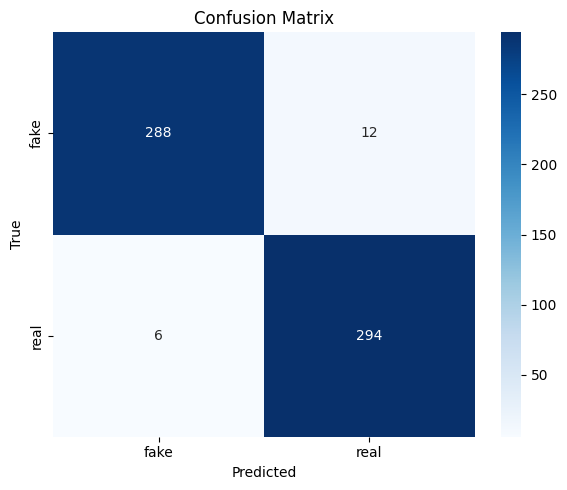

In [38]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=120)
plt.show()

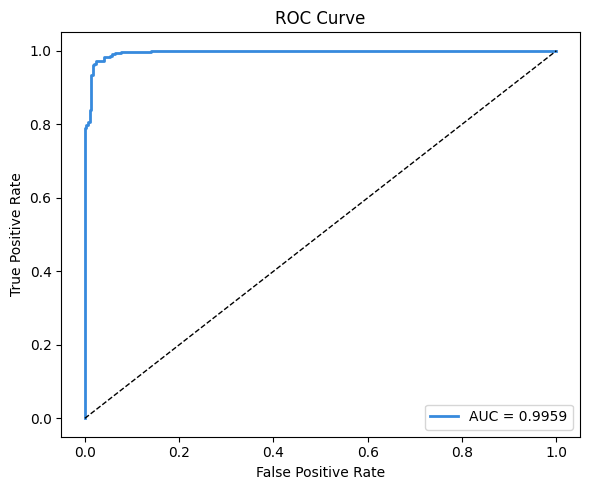

In [39]:
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='Blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=120)
plt.show()

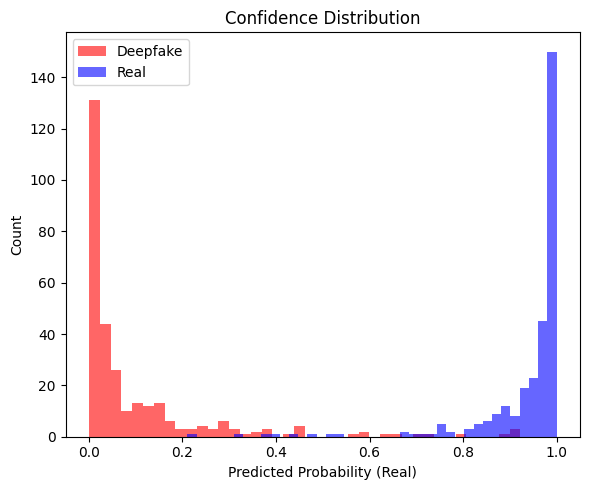

In [40]:
plt.figure(figsize=(6, 5))
plt.hist(y_probs[y_true == 0], bins=40, alpha=0.6, color='red',  label='Deepfake')
plt.hist(y_probs[y_true == 1], bins=40, alpha=0.6, color='blue', label='Real')
plt.xlabel('Predicted Probability (Real)')
plt.ylabel('Count')
plt.title('Confidence Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/confidence_dist.png', dpi=120)
plt.show()

Total misclassified: 18 / 600


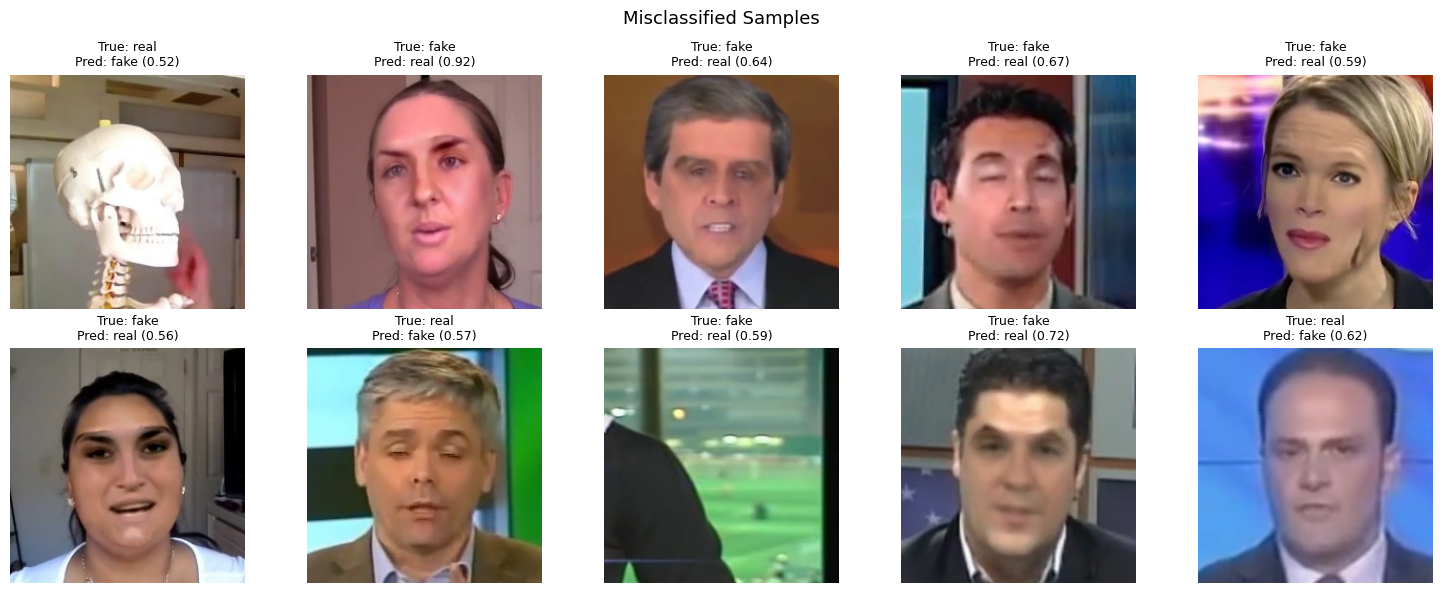

In [41]:
wrong_idx   = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)}")

n_show = min(10, len(wrong_idx))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(wrong_idx[:n_show]):
    img_path = test_df.iloc[idx]['file_name']
    img      = Image.open(img_path).convert('RGB').resize((224, 224))
    axes[i].imshow(img)
    true_label = le.classes_[y_true[idx]]
    pred_label = le.classes_[y_pred[idx]]
    conf       = y_probs[idx] if y_pred[idx] == 1 else 1 - y_probs[idx]
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.2f})", fontsize=9)
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Misclassified Samples', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/errors.png', dpi=120)
plt.show()

Default threshold (0.50) F1 : 0.9700
Optimal threshold (0.67) F1 : 0.9750


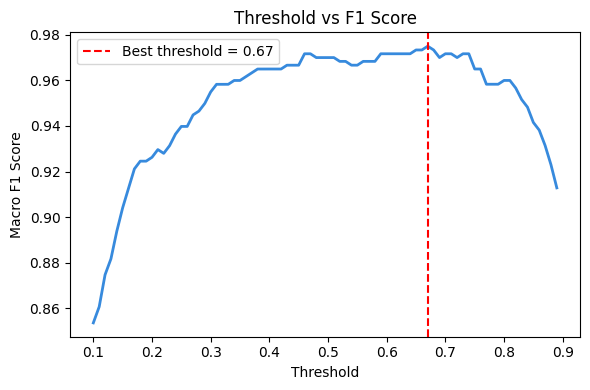

In [42]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_true, (y_probs >= t).astype(int), average='macro') for t in thresholds]
best_t     = thresholds[np.argmax(f1_scores)]
best_f1    = max(f1_scores)

print(f"Default threshold (0.50) F1 : {f1_score(y_true, (y_probs >= 0.50).astype(int), average='macro'):.4f}")
print(f"Optimal threshold ({best_t:.2f}) F1 : {best_f1:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, color='Blue', lw=2)
plt.axvline(best_t, color='red', linestyle='--', label=f'Best threshold = {best_t:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Macro F1 Score')
plt.title('Threshold vs F1 Score')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/threshold_tuning.png', dpi=120)
plt.show()